# 05 — Modelos Relacionais (M1, M2, M3)
## Modelagem multilabel relacional com co-ocorrência clínica

**Objetivo:** Treinar e comparar modelos que exploram dependências entre rótulos,
usando o baseline M0 como âncora de comparação.

**Modelos:**
- M1 — Classifier Chains (CC) sobre features do M0 congelado
- M2 — ResNet50 + BCE + regularização por co-ocorrência (λ·L_coo)
- M3 — ML-GCN (Chen et al., CVPR 2019) — ablação: 3 variantes × 3 τ

**Saídas:**
- `project/models/` — checkpoints M2/M3 por seed
- `project/results/05_relational_results.json` — métricas consolidadas
- `project/figs/` — figuras comparativas PT e EN

In [2]:
!pip install scikit-multilearn-ng torchtext -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.5 MB/s eta 0:00:00


In [3]:
!pip install -U gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.7 MB/s eta 0:00:0000:0100:01m


In [4]:
!nvidia-smi

Sun May 17 02:25:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os, json, hashlib, warnings, itertools
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from sklearn.metrics import (f1_score, hamming_loss, precision_score,
                             recall_score, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import ClassifierChain

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

warnings.filterwarnings("ignore")

# ── Colab paths ───────────────────────────────────────────────────────────────
import os
from pathlib import Path

# Verifica se estamos no ambiente do Colab (seja pelo browser ou via IDE conectada)
if os.path.exists('/content'):
    IN_COLAB = True
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            drive.mount('/content/drive')
    except:
        pass # Se falhar via IDE, assumimos que o drive já está montado ou mapeado
else:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path('/workspace')
    ZIP_PATH = ROOT / 'Dev' / 'Data' / 'Imgs.zip'
    LOCAL_IMGS = Path('/content/Imgs')
    if not LOCAL_IMGS.exists() and ZIP_PATH.exists():
        import zipfile
        print("Extraindo imagens para disco local...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall('/content/Imgs')
        print("Concluído.")
    IMGS_DIR = (LOCAL_IMGS / 'Imgs') if (LOCAL_IMGS / 'Imgs').exists() else LOCAL_IMGS
else:
    ROOT     = Path(r"/workspace")
    IMGS_DIR = ROOT / "Dev" / "Data" / "Imgs"

DATA_DIR    = ROOT / "Dev" / "Data"
CSV_PATH    = DATA_DIR / "Imgs-anotadas" / "dataset_labels.csv"
OUT_DIR     = ROOT / 'project'
SPLITS_DIR  = OUT_DIR / "splits"
MODELS_DIR  = OUT_DIR / "models"
GRAPHS_DIR  = OUT_DIR / "graphs"
RESULTS_DIR = OUT_DIR / "results"
FIGS_DIR    = OUT_DIR / "figs"

for d in [MODELS_DIR, RESULTS_DIR, FIGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CORE_COLS = ["ENANTEMA", "PÓLIPO", "ÚLCERA", "EROSÃO", "MICRONODULARIDADE"]
LABEL_EN  = {
    "ENANTEMA": "ENANTHEMA", "PÓLIPO": "POLYP", "ÚLCERA": "ULCER",
    "EROSÃO": "EROSION", "MICRONODULARIDADE": "MICRONODULARITY"
}
FOLDS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Mounted at /content/drive
Extraindo imagens para disco local...
Concluído.
Device: cuda


In [6]:
# ── Shared dataset, transforms, metric helpers ────────────────────────────────
class GastroDataset(Dataset):
    def __init__(self, df, imgs_dir, label_cols, transform=None):
        self.df         = df.reset_index(drop=True)
        self.imgs_dir   = Path(imgs_dir)
        self.label_cols = label_cols
        self.transform  = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(self.imgs_dir / row["image_name"]).convert("RGB")
        if self.transform: img = self.transform(img)
        lbl  = torch.tensor(row[self.label_cols].values.astype(float), dtype=torch.float32)
        return img, lbl, row["image_name"]


TF_TRAIN = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.15, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
TF_EVAL = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


def compute_pos_weights(df_tr, cols):
    return torch.tensor(
        [(df_tr[c] == 0).sum() / max(df_tr[c].sum(), 1) for c in cols],
        dtype=torch.float32)


def build_sampler(df_tr, cols):
    pw = [(df_tr[c] == 0).sum() / max(df_tr[c].sum(), 1) for c in cols]
    sw = [max((pw[i] if row[c] == 1 else 1.0) for i, c in enumerate(cols))
          for _, row in df_tr.iterrows()]
    return torch.utils.data.WeightedRandomSampler(
        torch.tensor(sw, dtype=torch.float32), len(sw), replacement=True)


def optimise_thresholds(probs, targets, cols):
    thr = {}
    for i, c in enumerate(cols):
        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.1, 0.91, 0.05):
            f1 = f1_score(targets[:, i], (probs[:, i] >= t).astype(int), zero_division=0)
            if f1 > best_f1: best_f1, best_t = f1, t
        thr[c] = round(float(best_t), 2)
    return thr


def compute_metrics(probs, targets, cols, thr=None):
    if thr is None: thr = {c: 0.5 for c in cols}
    preds = np.stack([(probs[:, i] >= thr[c]).astype(int)
                      for i, c in enumerate(cols)], axis=1)
    m = {}
    for i, c in enumerate(cols):
        m[f"f1_{c}"]    = round(f1_score(targets[:, i], preds[:, i], zero_division=0), 4)
        m[f"prec_{c}"]  = round(precision_score(targets[:, i], preds[:, i], zero_division=0), 4)
        m[f"rec_{c}"]   = round(recall_score(targets[:, i], preds[:, i], zero_division=0), 4)
        try: m[f"auprc_{c}"] = round(average_precision_score(targets[:, i], probs[:, i]), 4)
        except: m[f"auprc_{c}"] = None
    m["f1_macro"] = round(f1_score(targets, preds, average="macro", zero_division=0), 4)
    m["f1_micro"] = round(f1_score(targets, preds, average="micro", zero_division=0), 4)
    m["hamming"]  = round(hamming_loss(targets, preds), 4)
    mask = targets.sum(axis=1) >= 2
    m["f1_macro_multilabel"] = round(
        f1_score(targets[mask], preds[mask], average="macro", zero_division=0), 4) if mask.sum() > 0 else None
    m["n_multilabel_images"] = int(mask.sum())
    return m, preds


def inference(model, loader, device):
    model.eval()
    probs, tgts, names = [], [], []
    with torch.no_grad():
        for imgs, lbl, nm in loader:
            p = torch.sigmoid(model(imgs.to(device))).cpu().numpy()
            probs.append(p); tgts.append(lbl.numpy()); names.extend(list(nm))
    return np.vstack(probs), np.vstack(tgts), names


def make_param_groups(model, lr_bb, lr_hd):
    bb, hd = [], []
    for n, p in model.named_parameters():
        (hd if n.startswith("fc.") else bb).append(p)
    return [{"params": bb, "lr": lr_bb}, {"params": hd, "lr": lr_hd}]


print("Shared helpers defined.")

Shared helpers defined.


In [7]:
# ── Load splits + Evaluate M0 Baseline ──────────────────────────────
splits_all = {}
for i in range(FOLDS):
    df_tr = pd.read_csv(SPLITS_DIR / f"fold_{i}_train.csv")
    df_va = pd.read_csv(SPLITS_DIR / f"fold_{i}_val.csv")
    df_te = pd.read_csv(SPLITS_DIR / f"fold_{i}_test.csv")
    for col in CORE_COLS:
        for df in [df_tr, df_va, df_te]:
            df[col] = df[col].fillna(0).astype(int)
    splits_all[i] = {"train": df_tr, "val": df_va, "test": df_te}
    print(f"Fold {i}: train={len(df_tr)} val={len(df_va)} test={len(df_te)}")

print("\nEvaluating M0 Baseline on all Folds...")
m0_results = {}
for i in range(FOLDS):
    def build_resnet50_backbone_m0(n_labels):
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.fc.in_features, n_labels))
        return m
    model = build_resnet50_backbone_m0(len(CORE_COLS)).to(DEVICE)
    ckpt_path = MODELS_DIR / f"M0_BCE_fold{i}.pth"
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
    
    loader_va = DataLoader(GastroDataset(splits_all[i]["val"], IMGS_DIR, CORE_COLS, TF_EVAL),
                           batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
    loader_te = DataLoader(GastroDataset(splits_all[i]["test"], IMGS_DIR, CORE_COLS, TF_EVAL),
                           batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
    
    probs_va, tgts_va, _ = inference(model, loader_va, DEVICE)
    thr = optimise_thresholds(probs_va, tgts_va, CORE_COLS)
    
    probs_te, tgts_te, nm = inference(model, loader_te, DEVICE)
    m_te, preds_te = compute_metrics(probs_te, tgts_te, CORE_COLS, thr)
    
    m0_results[i] = {
        "thresholds": thr, "test_metrics": m_te,
        "test_predictions": {"image_names": nm,
                              "probs": probs_te.tolist(),
                              "preds": preds_te.tolist(),
                              "targets": tgts_te.tolist()}
    }

m0_agg = agg(m0_results, range(FOLDS)) if 'agg' in globals() else None
# We will aggregate M0 properly in the aggregation cell.


Fold 0: train=1353 val=239 test=398
Fold 1: train=1353 val=239 test=398
Fold 2: train=1353 val=239 test=398
Fold 3: train=1353 val=239 test=398
Fold 4: train=1353 val=239 test=398

Evaluating M0 Baseline on all Folds...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 433MB/s]


## 1. M1 — Classifier Chains sobre features do M0 congelado

In [8]:
# ── 1.1 Feature extractor from frozen M0 ─────────────────────────────────────
def build_resnet50_backbone(n_labels):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.fc.in_features, n_labels))
    return m


def load_m0_feature_extractor(ckpt_path, device):
    """Load M0 checkpoint and return a feature extractor (everything before fc)."""
    full_model = build_resnet50_backbone(len(CORE_COLS)).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    full_model.load_state_dict(ckpt)
    full_model.eval()

    # Strip classifier head — return 2048-dim pooled features
    class FeatureExtractor(nn.Module):
        def __init__(self, base):
            super().__init__()
            self.features = nn.Sequential(*list(base.children())[:-1])

        def forward(self, x):
            return self.features(x).squeeze(-1).squeeze(-1)  # (B, 2048)

    return FeatureExtractor(full_model).to(device)


@torch.no_grad()
def extract_features(extractor, loader, device):
    feats, tgts, names = [], [], []
    for imgs, lbl, nm in loader:
        feats.append(extractor(imgs.to(device)).cpu().numpy())
        tgts.append(lbl.numpy())
        names.extend(list(nm))
    return np.vstack(feats), np.vstack(tgts), names


print("M1 helpers defined.")

M1 helpers defined.


In [9]:
# ── 1.2 Train M1 (Classifier Chains) for all seeds ───────────────────────────
# CC order: clinical order (ENANTEMA→EROSÃO→ÚLCERA→PÓLIPO→MICRONODULARIDADE)
# Rationale: from most prevalent to rarest so rare classes benefit from richer context.
CC_ORDER = [0, 3, 2, 1, 4]  # indices into CORE_COLS

m1_results = {}

for i in range(FOLDS):
    print(f"── M1  fold {i} ──────────────────────────────")
    torch.manual_seed(42 + i); np.random.seed(42 + i)

    df_tr = splits_all[i]["train"]
    df_va = splits_all[i]["val"]
    df_te = splits_all[i]["test"]

    loader_tr = DataLoader(GastroDataset(df_tr, IMGS_DIR, CORE_COLS, TF_EVAL),
                           batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
    loader_va = DataLoader(GastroDataset(df_va, IMGS_DIR, CORE_COLS, TF_EVAL),
                           batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
    loader_te = DataLoader(GastroDataset(df_te, IMGS_DIR, CORE_COLS, TF_EVAL),
                           batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

    ckpt_path = MODELS_DIR / f"M0_BCE_fold{i}.pth"
    extractor = load_m0_feature_extractor(ckpt_path, DEVICE)

    X_tr, y_tr, _  = extract_features(extractor, loader_tr, DEVICE)
    X_va, y_va, _  = extract_features(extractor, loader_va, DEVICE)
    X_te, y_te, nm = extract_features(extractor, loader_te, DEVICE)
    print(f"  Features: train={X_tr.shape}  val={X_va.shape}  test={X_te.shape}")

    # Reorder columns for CC
    y_tr_cc = y_tr[:, CC_ORDER]
    y_va_cc = y_va[:, CC_ORDER]

    base_lr = LogisticRegression(C=1.0, max_iter=500, solver="lbfgs",
                                 class_weight="balanced", random_state=42+i)
    cc = ClassifierChain(base_lr, order=list(range(len(CORE_COLS))), random_state=42+i)
    cc.fit(X_tr, y_tr_cc)

    # Predict probabilities and reorder back to CORE_COLS order
    probs_va_cc = cc.predict_proba(X_va)[:, np.argsort(CC_ORDER)]
    probs_te_cc = cc.predict_proba(X_te)[:, np.argsort(CC_ORDER)]

    thr = optimise_thresholds(probs_va_cc, y_va, CORE_COLS)
    m_te, preds_te = compute_metrics(probs_te_cc, y_te, CORE_COLS, thr)

    print(f"  TEST F1-macro={m_te['f1_macro']:.4f}  Hamming={m_te['hamming']:.4f}")
    for c in CORE_COLS:
        print(f"    {c:22s}  F1={m_te[f'f1_{c}']:.3f}")

    m1_results[i] = {
        "thresholds": thr, "test_metrics": m_te,
        "test_predictions": {"image_names": nm,
                              "probs": probs_te_cc.tolist(),
                              "preds": preds_te.tolist(),
                              "targets": y_te.tolist()}
    }

print("\nM1 done.")

── M1  fold 0 ──────────────────────────────
  Features: train=(1353, 2048)  val=(239, 2048)  test=(398, 2048)
  TEST F1-macro=0.5083  Hamming=0.0528
    ENANTEMA                F1=0.613
    PÓLIPO                  F1=0.333
    ÚLCERA                  F1=0.518
    EROSÃO                  F1=0.676
    MICRONODULARIDADE       F1=0.400
── M1  fold 1 ──────────────────────────────
  Features: train=(1353, 2048)  val=(239, 2048)  test=(398, 2048)
  TEST F1-macro=0.5040  Hamming=0.0588
    ENANTEMA                F1=0.405
    PÓLIPO                  F1=0.545
    ÚLCERA                  F1=0.600
    EROSÃO                  F1=0.661
    MICRONODULARIDADE       F1=0.308
── M1  fold 2 ──────────────────────────────
  Features: train=(1353, 2048)  val=(239, 2048)  test=(398, 2048)
  TEST F1-macro=0.5592  Hamming=0.0573
    ENANTEMA                F1=0.535
    PÓLIPO                  F1=0.476
    ÚLCERA                  F1=0.553
    EROSÃO                  F1=0.686
    MICRONODULARIDADE       F1=0

## 2. M2 — ResNet50 + Regularização por co-ocorrência (λ·L_coo)

In [10]:
# ── 2.1 Co-occurrence regularisation loss ────────────────────────────────────
# L_coo = mean over pairs (i,j) with A_clin[i,j]>0 of:
#   A_clin[i,j] * (sigmoid(logit_i) - sigmoid(logit_j))^2
# Penalises cases where a strongly associated pair has divergent activations.
# Uses G_clin (seed-independent) so no leakage risk.

def coo_reg_loss(logits, A_clin_tensor):
    """
    logits:        (B, K)
    A_clin_tensor: (K, K) float, upper-triangle contains edge weights
    Returns scalar regularisation loss.
    """
    probs = torch.sigmoid(logits)  # (B, K)
    K = probs.shape[1]
    loss = torch.tensor(0.0, device=logits.device)
    n_pairs = 0
    for i in range(K):
        for j in range(i + 1, K):
            w = A_clin_tensor[i, j]
            if w > 0:
                # Modificado para regularização via Laplacian smoothing (aproxima as previsões)
                loss += (w * (probs[:, i] - probs[:, j])**2).mean()
                n_pairs += 1
    return loss / max(n_pairs, 1)


LAMBDA_COO = 0.3   # weight of regularisation term
print(f"M2: λ_coo = {LAMBDA_COO}")

M2: λ_coo = 0.3


In [11]:
# ── 2.2 Train M2 for all seeds ────────────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 50
LR_BACKBONE  = 1e-4
LR_HEAD      = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10

# Load G_clin (seed-independent, top-level graphs dir)
m2_results = {}

for i in range(FOLDS):
    print(f"{'='*55}\n M2  FOLD {i}\n{'='*55}")
    torch.manual_seed(42 + i); np.random.seed(42 + i)

    df_tr = splits_all[i]["train"]
    A_clin_np = np.load(GRAPHS_DIR / f"fold{i}" / "clin_tau00" / "adjacency.npy")
    A_CLIN = torch.tensor(A_clin_np, dtype=torch.float32).to(DEVICE)
    df_va = splits_all[i]["val"]
    df_te = splits_all[i]["test"]

    sampler   = build_sampler(df_tr, CORE_COLS)
    pos_w     = compute_pos_weights(df_tr, CORE_COLS).to(DEVICE)
    loader_tr = DataLoader(GastroDataset(df_tr, IMGS_DIR, CORE_COLS, TF_TRAIN),
                           batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=4, pin_memory=True)
    loader_va = DataLoader(GastroDataset(df_va, IMGS_DIR, CORE_COLS, TF_EVAL),
                           batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)
    loader_te = DataLoader(GastroDataset(df_te, IMGS_DIR, CORE_COLS, TF_EVAL),
                           batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)

    model     = build_resnet50_backbone(len(CORE_COLS)).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = optim.AdamW(make_param_groups(model, LR_BACKBONE, LR_HEAD),
                            weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=4, factor=0.5, min_lr=1e-6)

    best_f1, best_epoch, no_improve = 0.0, 0, 0
    best_state = None
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for imgs, labels, _ in loader_tr:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels) + LAMBDA_COO * coo_reg_loss(logits, A_CLIN)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(imgs)
        tr_loss = total_loss / len(loader_tr.dataset)

        probs_va, targets_va, _ = inference(model, loader_va, DEVICE)
        thr_va = optimise_thresholds(probs_va, targets_va, CORE_COLS)
        m_va, _ = compute_metrics(probs_va, targets_va, CORE_COLS, thr_va)
        val_f1  = m_va["f1_macro"]
        scheduler.step(val_f1)
        lr_now  = optimizer.param_groups[-1]["lr"]

        history.append({"epoch": epoch, "train_loss": round(tr_loss, 4),
                        "val_f1_macro": val_f1, "lr_head": round(lr_now, 7)})
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | loss={tr_loss:.4f} | val_F1={val_f1:.4f} | lr={lr_now:.2e}")

        if val_f1 > best_f1:
            best_f1, best_epoch, no_improve = val_f1, epoch, 0
            best_state = deepcopy(model.state_dict())
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"  Early stop @ ep{epoch}  (best={best_f1:.4f} @ ep{best_epoch})")
                break

    model.load_state_dict(best_state)
    probs_va_b, targets_va_b, _ = inference(model, loader_va, DEVICE)
    thr_te = optimise_thresholds(probs_va_b, targets_va_b, CORE_COLS)
    probs_te, targets_te, nm_te = inference(model, loader_te, DEVICE)
    m_te, preds_te = compute_metrics(probs_te, targets_te, CORE_COLS, thr_te)

    print(f"TEST F1-macro={m_te['f1_macro']:.4f}  Hamming={m_te['hamming']:.4f}")
    for c in CORE_COLS:
        print(f"    {c:22s}  F1={m_te[f'f1_{c}']:.3f}")

    ckpt_path = MODELS_DIR / f"M2_fold{i}.pt"
    torch.save({"model_state_dict": best_state, "label_cols": CORE_COLS,
                "thresholds": thr_te, "fold": i, "best_epoch": best_epoch,
                "val_f1_macro": best_f1, "lambda_coo": LAMBDA_COO}, ckpt_path)

    m2_results[i] = {
        "best_epoch": best_epoch, "val_f1_macro": round(best_f1, 4),
        "thresholds": thr_te, "test_metrics": m_te, "history": history,
        "test_predictions": {"image_names": nm_te,
                              "probs": probs_te.tolist(),
                              "preds": preds_te.tolist(),
                              "targets": targets_te.tolist()}
    }

print("\nM2 done.")

 M2  FOLD 0
  Epoch   1 | loss=2.1429 | val_F1=0.2553 | lr=1.00e-03
  Epoch   5 | loss=0.5594 | val_F1=0.3251 | lr=1.00e-03
  Epoch  10 | loss=0.3114 | val_F1=0.3519 | lr=1.00e-03
  Epoch  15 | loss=0.2381 | val_F1=0.3914 | lr=1.00e-03
  Epoch  20 | loss=0.1962 | val_F1=0.4835 | lr=1.00e-03
  Epoch  25 | loss=0.2145 | val_F1=0.4433 | lr=5.00e-04
  Epoch  30 | loss=0.1256 | val_F1=0.4866 | lr=5.00e-04
  Epoch  35 | loss=0.1146 | val_F1=0.4470 | lr=5.00e-04
  Epoch  40 | loss=0.1091 | val_F1=0.4875 | lr=2.50e-04
  Early stop @ ep43  (best=0.4890 @ ep33)
TEST F1-macro=0.6015  Hamming=0.0497
    ENANTEMA                F1=0.610
    PÓLIPO                  F1=0.667
    ÚLCERA                  F1=0.593
    EROSÃO                  F1=0.710
    MICRONODULARIDADE       F1=0.429
 M2  FOLD 1
  Epoch   1 | loss=2.1470 | val_F1=0.2421 | lr=1.00e-03
  Epoch   5 | loss=0.5441 | val_F1=0.3641 | lr=1.00e-03
  Epoch  10 | loss=0.4739 | val_F1=0.3927 | lr=1.00e-03
  Epoch  15 | loss=0.2466 | val_F1=0.490

## 3. M3 — ML-GCN (ablação: 3 variantes × 3 τ)

In [12]:
# ── 3.1 GCN label-embedding module ───────────────────────────────────────────
import gensim.downloader as api

print("Loading GloVe 300d embeddings via Gensim (this may take a minute on the first run)...")
try:
    glove = api.load("glove-wiki-gigaword-300")
    has_glove = True
except Exception as e:
    print("GloVe not found or download failed. Using random embeddings.", e)
    has_glove = False

def get_label_embeddings(labels_en):
    if has_glove:
        # Pega o vetor 300d se a palavra existir no vocab, caso contrário um vetor aleatório
        return torch.stack([torch.tensor(glove[l.lower()]) if l.lower() in glove else torch.randn(300) for l in labels_en])
    else:
        return torch.randn(len(labels_en), 300)

class MLGCN(nn.Module):
    def __init__(self, K, label_embeddings, hidden=256, p=0.0):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        emb_dim = label_embeddings.shape[1]
        self.gcn1 = nn.Linear(emb_dim, hidden, bias=False)
        self.gcn2 = nn.Linear(hidden, 2048, bias=False)
        self.relu = nn.LeakyReLU(0.2)
        self.label_emb = nn.Parameter(label_embeddings, requires_grad=False)
        self.p = p

    def reweight_adj(self, A):
        A_bin = (A >= self.p).float()
        A_bin = A_bin + torch.eye(A_bin.shape[0], device=A_bin.device)  # Add self connections
        A_bin[A_bin > 1] = 1.0
        D_inv = torch.diag(1.0 / (A_bin.sum(dim=1) + 1e-8))
        return D_inv @ A_bin

    def forward(self, imgs, A, device):
        feat = self.backbone(imgs).squeeze(-1).squeeze(-1)  # (B, 2048)
        A_norm = self.reweight_adj(A)
        H = self.relu(A_norm @ self.gcn1(self.label_emb))
        concepts = A_norm @ self.gcn2(H)                    # (K, 2048)
        return feat @ concepts.T                             # (B, K)

print("ML-GCN architecture defined.")


Loading GloVe 300d embeddings via Gensim (this may take a minute on the first run)...
[==================================================] 100.0% 376.1/376.1MB downloaded
ML-GCN architecture defined.


In [13]:
# ── 3.2 M3 training loop (ablation: variant × tau × seed) ────────────────────
GCN_VARIANTS = ["emp", "pmi", "clin"]
GCN_TAUS     = ["00", "01", "03"]   # tau strings matching directory names
GCN_HIDDEN   = 256

m3_results = {}  # key: (variant, tau_str, seed)

for variant, tau_str in itertools.product(GCN_VARIANTS, GCN_TAUS):
    for i in range(FOLDS):
        run_key = f"{variant}_tau{tau_str}_fold{i}"
        print(f"\n{'='*55}\n M3  {run_key}\n{'='*55}")
        torch.manual_seed(42 + i); np.random.seed(42 + i)

        # Load per-seed adjacency_norm
        adj_path = GRAPHS_DIR / f"fold{i}" / f"{variant}_tau{tau_str}" / "adjacency.npy"
        A_norm_np = np.load(adj_path)
        A_NORM = torch.tensor(A_norm_np, dtype=torch.float32).to(DEVICE)

        df_tr = splits_all[i]["train"]
        df_va = splits_all[i]["val"]
        df_te = splits_all[i]["test"]

        sampler   = build_sampler(df_tr, CORE_COLS)
        pos_w     = compute_pos_weights(df_tr, CORE_COLS).to(DEVICE)
        loader_tr = DataLoader(GastroDataset(df_tr, IMGS_DIR, CORE_COLS, TF_TRAIN),
                               batch_size=BATCH_SIZE, sampler=sampler,
                               num_workers=4, pin_memory=True)
        loader_va = DataLoader(GastroDataset(df_va, IMGS_DIR, CORE_COLS, TF_EVAL),
                               batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=4, pin_memory=True)
        loader_te = DataLoader(GastroDataset(df_te, IMGS_DIR, CORE_COLS, TF_EVAL),
                               batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=4, pin_memory=True)

        emb = get_label_embeddings([LABEL_EN[c] for c in CORE_COLS]).to(DEVICE)
        model = MLGCN(K=len(CORE_COLS), label_embeddings=emb, hidden=GCN_HIDDEN, p=0.0).to(DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

        # Separate LR for backbone vs GCN head
        backbone_params, gcn_params = [], []
        for n, p in model.named_parameters():
            (gcn_params if "gcn" in n else backbone_params).append(p)
        optimizer = optim.AdamW(
            [{"params": backbone_params, "lr": LR_BACKBONE},
             {"params": gcn_params,      "lr": LR_HEAD}],
            weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", patience=4, factor=0.5, min_lr=1e-6)

        best_f1, best_epoch, no_improve = 0.0, 0, 0
        best_state = None
        history = []

        ckpt_path = MODELS_DIR / f"M3_{run_key}.pt"
        if ckpt_path.exists():
            print("  [✓] Checkpoint encontrado! Pulando treinamento...")
            ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
            model.load_state_dict(ckpt["model_state_dict"])
            best_epoch = ckpt.get("best_epoch", 0)
            best_f1 = ckpt.get("val_f1_macro", 0.0)
            history = []
            best_state = ckpt["model_state_dict"]
        else:
            for epoch in range(1, EPOCHS + 1):
                model.train()
                total_loss = 0.0
                for imgs, labels, _ in loader_tr:
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    logits = model(imgs, A_NORM, DEVICE)
                    loss   = criterion(logits, labels)
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
                    total_loss += loss.item() * len(imgs)
                tr_loss = total_loss / len(loader_tr.dataset)

                # Validation inference
                model.eval()
                probs_list, tgt_list = [], []
                with torch.no_grad():
                    for imgs, lbl, _ in loader_va:
                        p = torch.sigmoid(model(imgs.to(DEVICE), A_NORM, DEVICE)).cpu().numpy()
                        probs_list.append(p); tgt_list.append(lbl.numpy())
                probs_va = np.vstack(probs_list); targets_va = np.vstack(tgt_list)

                thr_va = optimise_thresholds(probs_va, targets_va, CORE_COLS)
                m_va, _ = compute_metrics(probs_va, targets_va, CORE_COLS, thr_va)
                val_f1  = m_va["f1_macro"]
                scheduler.step(val_f1)
                lr_now = optimizer.param_groups[-1]["lr"]

                history.append({"epoch": epoch, "train_loss": round(tr_loss, 4),
                                "val_f1_macro": val_f1, "lr": round(lr_now, 7)})
                if epoch % 5 == 0 or epoch == 1:
                    print(f"  Ep {epoch:3d} | loss={tr_loss:.4f} | val_F1={val_f1:.4f} | lr={lr_now:.2e}")

                if val_f1 > best_f1:
                    best_f1, best_epoch, no_improve = val_f1, epoch, 0
                    best_state = deepcopy(model.state_dict())
                else:
                    no_improve += 1
                    if no_improve >= PATIENCE:
                        print(f"  Early stop @ ep{epoch}  (best={best_f1:.4f} @ ep{best_epoch})")
                        break

        # Evaluate
        model.load_state_dict(best_state)
        model.eval()
        probs_list, tgt_list, nm_list = [], [], []
        with torch.no_grad():
            for imgs, lbl, nm in loader_va:
                p = torch.sigmoid(model(imgs.to(DEVICE), A_NORM, DEVICE)).cpu().numpy()
                probs_list.append(p); tgt_list.append(lbl.numpy())
        probs_va_b = np.vstack(probs_list); targets_va_b = np.vstack(tgt_list)
        thr_te = optimise_thresholds(probs_va_b, targets_va_b, CORE_COLS)

        probs_list, tgt_list, nm_list = [], [], []
        with torch.no_grad():
            for imgs, lbl, nm in loader_te:
                p = torch.sigmoid(model(imgs.to(DEVICE), A_NORM, DEVICE)).cpu().numpy()
                probs_list.append(p); tgt_list.append(lbl.numpy()); nm_list.extend(list(nm))
        probs_te = np.vstack(probs_list); targets_te = np.vstack(tgt_list)
        m_te, preds_te = compute_metrics(probs_te, targets_te, CORE_COLS, thr_te)

        print(f"TEST F1-macro={m_te['f1_macro']:.4f}  Hamming={m_te['hamming']:.4f}")
        for c in CORE_COLS:
            print(f"    {c:22s}  F1={m_te[f'f1_{c}']:.3f}")

        ckpt_path = MODELS_DIR / f"M3_{run_key}.pt"
        torch.save({"model_state_dict": best_state, "label_cols": CORE_COLS,
                    "thresholds": thr_te, "fold": i, "variant": variant,
                    "tau_str": tau_str, "best_epoch": best_epoch,
                    "val_f1_macro": best_f1}, ckpt_path)

        m3_results[run_key] = {
            "variant": variant, "tau_str": tau_str, "fold": i,
            "best_epoch": best_epoch, "val_f1_macro": round(best_f1, 4),
            "thresholds": thr_te, "test_metrics": m_te, "history": history,
            "test_predictions": {"image_names": nm_list,
                                  "probs": probs_te.tolist(),
                                  "preds": preds_te.tolist(),
                                  "targets": targets_te.tolist()}
        }

print("\nM3 ablation done.")


 M3  emp_tau00_fold0
  [✓] Checkpoint encontrado! Pulando treinamento...
TEST F1-macro=0.1897  Hamming=0.2583
    ENANTEMA                F1=0.183
    PÓLIPO                  F1=0.214
    ÚLCERA                  F1=0.062
    EROSÃO                  F1=0.307
    MICRONODULARIDADE       F1=0.182

 M3  emp_tau00_fold1
  [✓] Checkpoint encontrado! Pulando treinamento...
TEST F1-macro=0.2918  Hamming=0.1799
    ENANTEMA                F1=0.310
    PÓLIPO                  F1=0.273
    ÚLCERA                  F1=0.340
    EROSÃO                  F1=0.455
    MICRONODULARIDADE       F1=0.082

 M3  emp_tau00_fold2
  [✓] Checkpoint encontrado! Pulando treinamento...
TEST F1-macro=0.2705  Hamming=0.1829
    ENANTEMA                F1=0.263
    PÓLIPO                  F1=0.138
    ÚLCERA                  F1=0.357
    EROSÃO                  F1=0.382
    MICRONODULARIDADE       F1=0.213

 M3  emp_tau00_fold3
  [✓] Checkpoint encontrado! Pulando treinamento...
TEST F1-macro=0.3389  Hamming=0.1327
 

## 4. Análise de resultados e comparação estatística

In [14]:
# ── 4.1 Aggregate metrics across seeds ───────────────────────────────────────
def agg(results_dict, folds=range(FOLDS)):
    """Mean ± std of test_metrics across seeds for a model results dict."""
    metric_keys = (["f1_macro","f1_micro","hamming","f1_macro_multilabel"]
                   + [f"f1_{c}" for c in CORE_COLS]
                   + [f"auprc_{c}" for c in CORE_COLS])
    out = {}
    for k in metric_keys:
        vals = [results_dict[s]["test_metrics"].get(k) for s in folds
                if results_dict[s]["test_metrics"].get(k) is not None]
        if vals:
            out[k] = {"mean": round(float(np.mean(vals)), 4),
                      "std":  round(float(np.std(vals)),  4)}
    return out


m0_agg = agg(m0_results, range(FOLDS))
m1_agg = agg(m1_results)
m2_agg = agg(m2_results)

# Best M3 config = highest mean F1-macro across seeds
m3_agg_all = {}
for variant, tau_str in itertools.product(GCN_VARIANTS, GCN_TAUS):
    key = f"{variant}_tau{tau_str}"
    sub = {s: m3_results[f"{key}_fold{s}"] for s in range(FOLDS)}
    m3_agg_all[key] = agg(sub)

best_m3_key = max(m3_agg_all, key=lambda k: m3_agg_all[k]["f1_macro"]["mean"])
m3_best_agg = m3_agg_all[best_m3_key]
print(f"Best M3 config: {best_m3_key}")

# Summary table
rows = []
for model_name, ag in [("M0", m0_agg), ("M1_CC", m1_agg),
                        ("M2_coo", m2_agg), (f"M3_{best_m3_key}", m3_best_agg)]:
    row = {"model": model_name,
           "F1-macro": f"{ag['f1_macro']['mean']:.3f}±{ag['f1_macro']['std']:.3f}",
           "Hamming":  f"{ag['hamming']['mean']:.4f}±{ag['hamming']['std']:.4f}"}
    for c in CORE_COLS:
        k = f"f1_{c}"
        row[f"F1-{c[:4]}"] = f"{ag[k]['mean']:.3f}±{ag[k]['std']:.3f}" if k in ag else "—"
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index("model")
print("\nSummary (mean ± std, 3 seeds):")
display(df_summary)

Best M3 config: clin_tau01

Summary (mean ± std, 3 seeds):


,F1-macro,Hamming,F1-ENAN,F1-PÓLI,F1-ÚLCE,F1-EROS,F1-MICR
model,,,,,,,
M0,0.517±0.045,0.0632±0.0054,0.538±0.037,0.506±0.110,0.520±0.101,0.670±0.020,0.351±0.184
M1_CC,0.519±0.028,0.0547±0.0028,0.498±0.071,0.535±0.136,0.511±0.072,0.665±0.014,0.384±0.136
M2_coo,0.537±0.041,0.0659±0.0084,0.470±0.083,0.624±0.042,0.555±0.099,0.629±0.047,0.408±0.136
M3_clin_tau01,0.323±0.023,0.1619±0.0314,0.296±0.045,0.307±0.081,0.298±0.069,0.474±0.066,0.238±0.126


In [15]:
# ── 4.2 Bootstrap CI vs M0 ──────────────────────
N_BOOT = 2000
RNG    = np.random.default_rng(42)

def bootstrap_f1macro_pooled(res_dict):
    all_tgts, all_preds = [], []
    for i in range(FOLDS):
        all_tgts.append(np.array(res_dict[i]["test_predictions"]["targets"]))
        all_preds.append(np.array(res_dict[i]["test_predictions"]["preds"]))
    tgts = np.vstack(all_tgts)
    preds = np.vstack(all_preds)
    
    scores = []
    N = len(tgts)
    for _ in range(N_BOOT):
        idx = RNG.integers(0, N, N)
        scores.append(f1_score(tgts[idx], preds[idx], average="macro", zero_division=0))
    return np.array(scores)

print("Calculando Bootstrap CI (2000 amostras) pooled over 5 folds...")

stat_rows = []
best_m3_sub = {i: m3_results[f"{best_m3_key}_fold{i}"] for i in range(FOLDS)}
for model_name, res in [("M0", m0_results), ("M1_CC", m1_results), ("M2_coo", m2_results), (f"M3_{best_m3_key}", best_m3_sub)]:
    scores = bootstrap_f1macro_pooled(res)
    stat_rows.append({
        "model": model_name,
        "F1-macro pooled": round(np.mean(scores), 4),
        "95% CI": f"[{np.percentile(scores, 2.5):.4f}, {np.percentile(scores, 97.5):.4f}]"
    })

df_stat = pd.DataFrame(stat_rows).set_index("model")
print("Bootstrap F1-macro vs M0:")
display(df_stat)


Calculando Bootstrap CI (2000 amostras) pooled over 5 folds...
Bootstrap F1-macro vs M0:


,F1-macro pooled,95% CI
model,,
M0,0.5144,"[0.4736, 0.5543]"
M1_CC,0.5148,"[0.4639, 0.5621]"
M2_coo,0.5240,"[0.4821, 0.5665]"
M3_clin_tau01,0.2920,"[0.2663, 0.3181]"


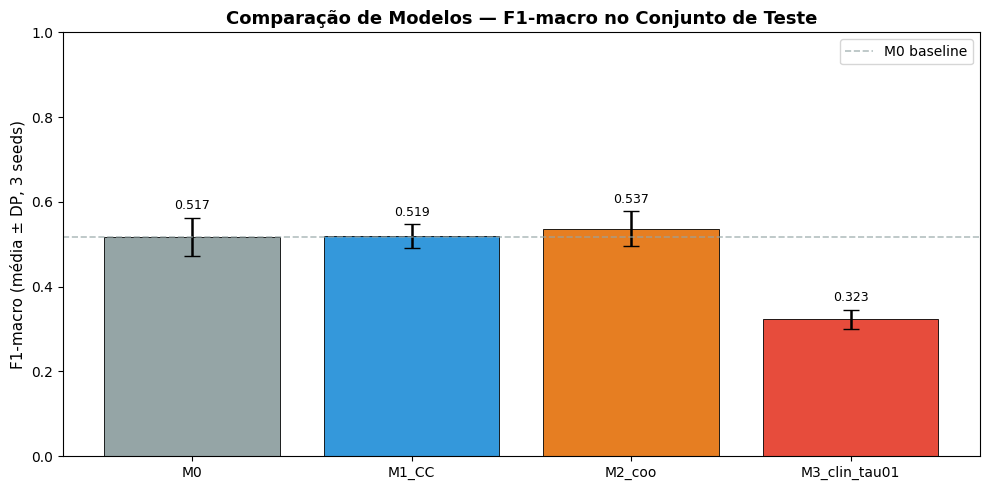

In [16]:
# ── 4.3 Figure: F1-macro comparison M0→M1→M2→M3 (PT) ────────────────────────
models_plot = ["M0", "M1_CC", "M2_coo", f"M3_{best_m3_key}"]
agg_list    = [m0_agg, m1_agg, m2_agg, m3_best_agg]
means_p = [ag["f1_macro"]["mean"] for ag in agg_list]
stds_p  = [ag["f1_macro"]["std"]  for ag in agg_list]
colors  = ["#95a5a6", "#3498db", "#e67e22", "#e74c3c"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models_plot, means_p, yerr=stds_p, capsize=6,
              color=colors, edgecolor="black", lw=0.6, error_kw={"lw": 1.8})
ax.axhline(means_p[0], color="#95a5a6", linestyle="--", lw=1.2, alpha=0.7, label="M0 baseline")
ax.set_ylabel("F1-macro (média ± DP, 3 seeds)", fontsize=11)
ax.set_title("Comparação de Modelos — F1-macro no Conjunto de Teste", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.legend()
for bar, m, s in zip(bars, means_p, stds_p):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.02,
            f"{m:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / "18_model_comparison_f1macro_PT.png", dpi=150, bbox_inches="tight")
plt.show()

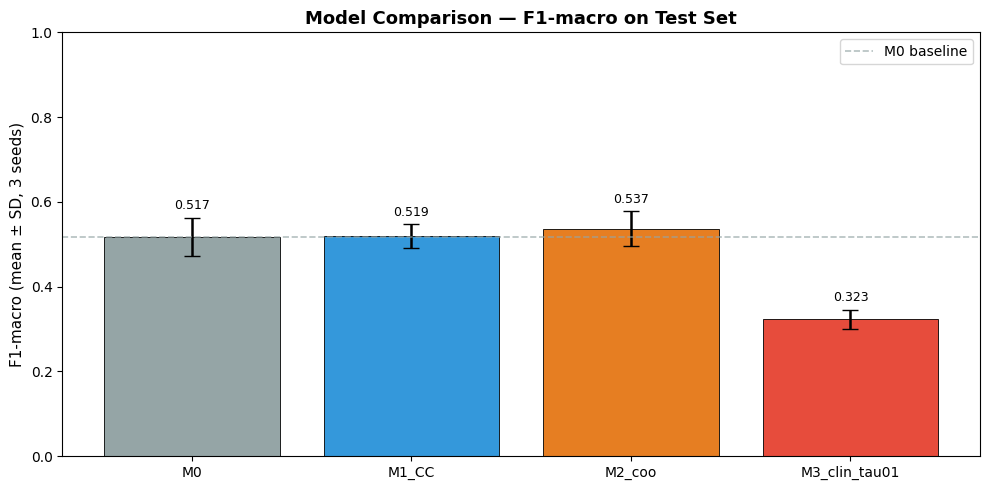

In [17]:
# ── 4.4 Figure: F1-macro comparison (EN) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models_plot, means_p, yerr=stds_p, capsize=6,
              color=colors, edgecolor="black", lw=0.6, error_kw={"lw": 1.8})
ax.axhline(means_p[0], color="#95a5a6", linestyle="--", lw=1.2, alpha=0.7, label="M0 baseline")
ax.set_ylabel("F1-macro (mean ± SD, 3 seeds)", fontsize=11)
ax.set_title("Model Comparison — F1-macro on Test Set", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.legend()
for bar, m, s in zip(bars, means_p, stds_p):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.02,
            f"{m:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / "18_model_comparison_f1macro_EN.png", dpi=150, bbox_inches="tight")
plt.show()

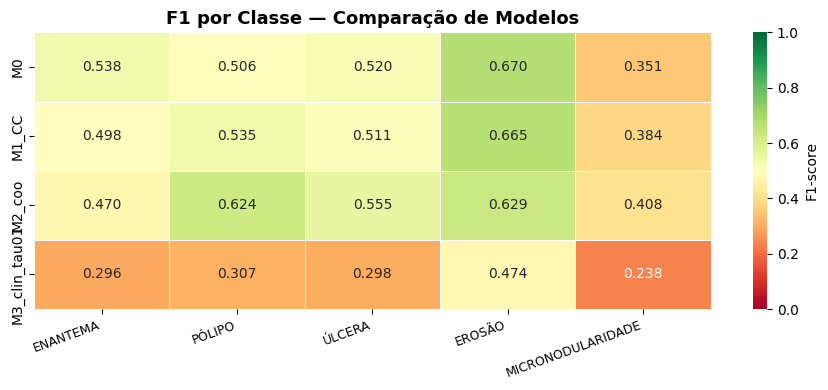

In [18]:
# ── 4.5 Figure: per-class F1 heatmap — all models (PT) ───────────────────────
heat_data = {}
for model_name, ag in [("M0", m0_agg), ("M1_CC", m1_agg),
                        ("M2_coo", m2_agg), (f"M3_{best_m3_key}", m3_best_agg)]:
    heat_data[model_name] = {c: ag[f"f1_{c}"]["mean"] for c in CORE_COLS}

df_heat = pd.DataFrame(heat_data, index=CORE_COLS).T

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(df_heat, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "F1-score"})
ax.set_title("F1 por Classe — Comparação de Modelos", fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / "19_f1_heatmap_models_PT.png", dpi=150, bbox_inches="tight")
plt.show()

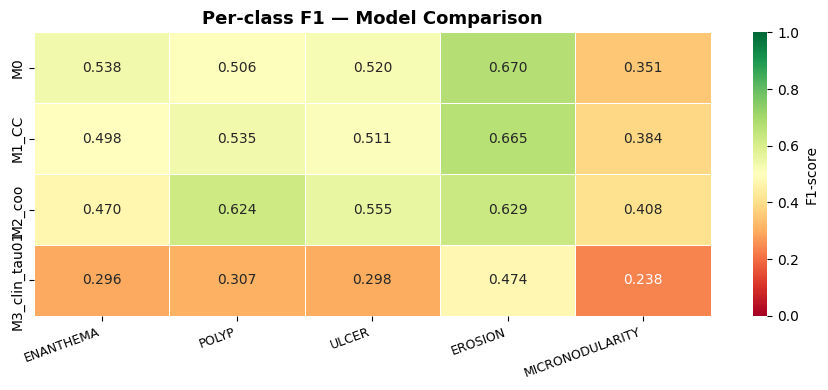

In [19]:
# ── 4.6 Figure: per-class F1 heatmap (EN) ────────────────────────────────────
heat_data_en = {}
for model_name, ag in [("M0", m0_agg), ("M1_CC", m1_agg),
                        ("M2_coo", m2_agg), (f"M3_{best_m3_key}", m3_best_agg)]:
    heat_data_en[model_name] = {LABEL_EN[c]: ag[f"f1_{c}"]["mean"] for c in CORE_COLS}

df_heat_en = pd.DataFrame(heat_data_en, index=[LABEL_EN[c] for c in CORE_COLS]).T

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(df_heat_en, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "F1-score"})
ax.set_title("Per-class F1 — Model Comparison", fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / "19_f1_heatmap_models_EN.png", dpi=150, bbox_inches="tight")
plt.show()

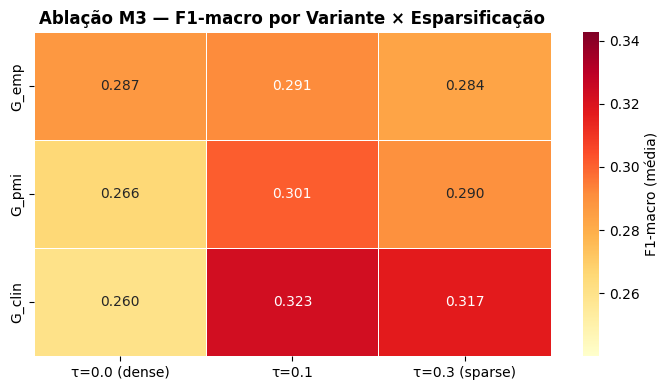

In [20]:
# ── 4.7 M3 ablation heatmap — F1-macro por variante × τ (PT) ─────────────────
ablation_data = np.zeros((len(GCN_VARIANTS), len(GCN_TAUS)))
tau_labels    = ["τ=0.0 (dense)", "τ=0.1", "τ=0.3 (sparse)"]

for vi, variant in enumerate(GCN_VARIANTS):
    for ti, tau_str in enumerate(GCN_TAUS):
        key = f"{variant}_tau{tau_str}"
        ablation_data[vi, ti] = m3_agg_all[key]["f1_macro"]["mean"]

df_abl = pd.DataFrame(ablation_data, index=["G_emp","G_pmi","G_clin"],
                      columns=tau_labels)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(df_abl, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=ablation_data.min() - 0.02, vmax=ablation_data.max() + 0.02,
            linewidths=0.5, ax=ax, cbar_kws={"label": "F1-macro (média)"})
ax.set_title("Ablação M3 — F1-macro por Variante × Esparsificação",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "20_m3_ablation_heatmap_PT.png", dpi=150, bbox_inches="tight")
plt.show()

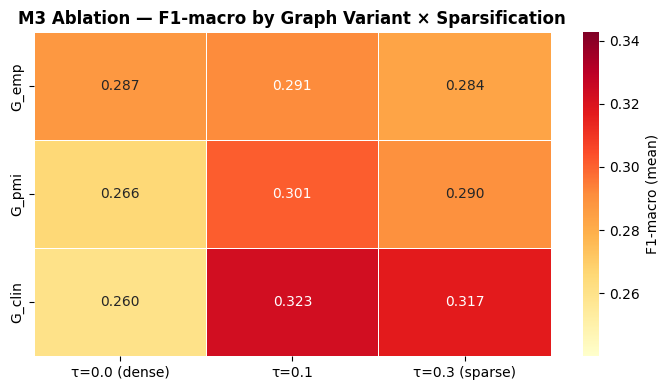

In [21]:
# ── 4.8 M3 ablation heatmap (EN) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(df_abl, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=ablation_data.min() - 0.02, vmax=ablation_data.max() + 0.02,
            linewidths=0.5, ax=ax, cbar_kws={"label": "F1-macro (mean)"})
ax.set_title("M3 Ablation — F1-macro by Graph Variant × Sparsification",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "20_m3_ablation_heatmap_EN.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Consolidação em JSON

In [22]:
# ── 5.1 Build and save JSON ───────────────────────────────────────────────────
import json as _json

class SafeEncoder(_json.JSONEncoder):
    def default(self, o):
        if isinstance(o, (np.integer,)):  return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, np.ndarray):     return o.tolist()
        if isinstance(o, bool):           return bool(o)
        return super().default(o)

report = {
    "metadata": {
        "notebook": "05_relational_models",
        "folds": list(range(FOLDS)),
        "core_labels": CORE_COLS,
        "batch_size": BATCH_SIZE, "epochs_max": EPOCHS,
        "lr_backbone": LR_BACKBONE, "lr_head": LR_HEAD,
        "early_stopping_patience": PATIENCE,
        "lambda_coo_m2": LAMBDA_COO,
        "gcn_hidden": GCN_HIDDEN,
        "best_m3_config": best_m3_key,
    },
    "M0_anchor": m0_agg,
    "M1_CC": {
        "per_seed": {str(s): {"test_metrics": m1_results[s]["test_metrics"],
                               "thresholds":   m1_results[s]["thresholds"]}
                     for s in range(FOLDS)},
        "aggregated": m1_agg,
    },
    "M2_coo": {
        "per_seed": {str(s): {"test_metrics":  m2_results[s]["test_metrics"],
                               "thresholds":    m2_results[s]["thresholds"],
                               "best_epoch":    m2_results[s]["best_epoch"],
                               "val_f1_macro":  m2_results[s]["val_f1_macro"]}
                     for s in range(FOLDS)},
        "aggregated": m2_agg,
    },
    "M3_ablation": {
        k: {"aggregated": m3_agg_all[k],
            "per_seed": {str(s): {"test_metrics": m3_results[f"{k}_fold{s}"]["test_metrics"],
                                   "best_epoch":   m3_results[f"{k}_fold{s}"]["best_epoch"],
                                   "val_f1_macro": m3_results[f"{k}_fold{s}"]["val_f1_macro"]}
                         for s in range(FOLDS)}}
        for k in m3_agg_all
    },
    "statistical_tests": df_stat.reset_index().to_dict(orient="records") if "df_stat" in globals() else {},
}

out_path = RESULTS_DIR / "05_relational_results.json"
with open(out_path, "w", encoding="utf-8") as f:
    _json.dump(report, f, indent=2, ensure_ascii=False, cls=SafeEncoder)

print(f"Saved: {out_path}")
print(f"  M1 F1-macro: {m1_agg['f1_macro']['mean']:.3f} ± {m1_agg['f1_macro']['std']:.3f}")
print(f"  M2 F1-macro: {m2_agg['f1_macro']['mean']:.3f} ± {m2_agg['f1_macro']['std']:.3f}")
print(f"  M3 best ({best_m3_key}) F1-macro: {m3_best_agg['f1_macro']['mean']:.3f} ± {m3_best_agg['f1_macro']['std']:.3f}")
print(f"  M0 anchor:   {m0_agg['f1_macro']['mean']:.3f} ± {m0_agg['f1_macro']['std']:.3f}")

Saved: /workspace/project/results/05_relational_results.json
  M1 F1-macro: 0.519 ± 0.028
  M2 F1-macro: 0.537 ± 0.041
  M3 best (clin_tau01) F1-macro: 0.323 ± 0.023
  M0 anchor:   0.517 ± 0.045


## 6. Resumo executivo

In [23]:
print("=" * 65)
print("NB05 — RELATIONAL MODELS — SUMMARY")
print("=" * 65)
print(f"\nBaseline M0 (anchor):  F1-macro = {m0_agg['f1_macro']['mean']:.3f} ± {m0_agg['f1_macro']['std']:.3f}")
print(f"M1 Classifier Chains:  F1-macro = {m1_agg['f1_macro']['mean']:.3f} ± {m1_agg['f1_macro']['std']:.3f}  Δ={m1_agg['f1_macro']['mean']-m0_agg['f1_macro']['mean']:+.3f}")
print(f"M2 BCE+L_coo (λ={LAMBDA_COO}): F1-macro = {m2_agg['f1_macro']['mean']:.3f} ± {m2_agg['f1_macro']['std']:.3f}  Δ={m2_agg['f1_macro']['mean']-m0_agg['f1_macro']['mean']:+.3f}")
print(f"M3 ML-GCN best ({best_m3_key}):")
print(f"              F1-macro = {m3_best_agg['f1_macro']['mean']:.3f} ± {m3_best_agg['f1_macro']['std']:.3f}  Δ={m3_best_agg['f1_macro']['mean']-m0_agg['f1_macro']['mean']:+.3f}")

print("\nPer-class F1 — best model vs M0:")
print(f"  {'Class':22s}  {'M0':>6}  {'Best':>6}  {'Δ':>6}")
for c in CORE_COLS:
    m0_f1   = m0_agg[f"f1_{c}"]["mean"]
    best_f1 = m3_best_agg[f"f1_{c}"]["mean"]
    print(f"  {c:22s}  {m0_f1:.3f}   {best_f1:.3f}   {best_f1-m0_f1:+.3f}")

print("\nStatistical tests (Bootstrap 95% CI vs M0):")
display(df_stat)

print("\nOutputs:")
print(f"  figures 18-20 (PT+EN): {FIGS_DIR}")
print(f"  JSON: {RESULTS_DIR}/05_relational_results.json")
print(f"  checkpoints: {MODELS_DIR}/M2_fold*.pt, M3_*.pt")
print("=" * 65)

NB05 — RELATIONAL MODELS — SUMMARY

Baseline M0 (anchor):  F1-macro = 0.517 ± 0.045
M1 Classifier Chains:  F1-macro = 0.519 ± 0.028  Δ=+0.002
M2 BCE+L_coo (λ=0.3): F1-macro = 0.537 ± 0.041  Δ=+0.020
M3 ML-GCN best (clin_tau01):
              F1-macro = 0.323 ± 0.023  Δ=-0.195

Per-class F1 — best model vs M0:
  Class                       M0    Best       Δ
  ENANTEMA                0.538   0.296   -0.242
  PÓLIPO                  0.506   0.307   -0.200
  ÚLCERA                  0.520   0.298   -0.222
  EROSÃO                  0.670   0.474   -0.196
  MICRONODULARIDADE       0.351   0.238   -0.113

Statistical tests (Bootstrap 95% CI vs M0):


,F1-macro pooled,95% CI
model,,
M0,0.5144,"[0.4736, 0.5543]"
M1_CC,0.5148,"[0.4639, 0.5621]"
M2_coo,0.5240,"[0.4821, 0.5665]"
M3_clin_tau01,0.2920,"[0.2663, 0.3181]"



Outputs:
  figures 18-20 (PT+EN): /workspace/project/figs
  JSON: /workspace/project/results/05_relational_results.json
  checkpoints: /workspace/project/models/M2_fold*.pt, M3_*.pt
